In [1]:
import numpy as np
import pandas as pd
import pymcdm

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
alpha = 0.88    # Sensitivity to gains
beta = 0.88     # Sensitivity to losses
lambda_ = 2.25  # Loss aversion parameter

def prospect_value(x, alpha=0.88, beta=0.88, loss_aversion=2.25):
    return np.where(
        x >= 0,
        x ** alpha,
        -loss_aversion * ((-x) ** beta)
    )

def prospect_theory_value_vis(x, neutral_value, criteria_type, alpha=alpha, lambda_=lambda_):
    x_diff = x - neutral_value
    if criteria_type == -1:
        x_diff = - x_diff

    values = np.where(x_diff >= 0, x_diff ** alpha, -lambda_ * (-x_diff) ** alpha)  

    return values 

def prospect_theory_value_matrix(value, neutral_value, criteria_type, alpha=alpha, beta=beta, lambda_=lambda_):
    diff = value - neutral_value

    if criteria_type == 1:
        if diff > 0:    
            return (value - neutral_value)**alpha
        return -lambda_ * (-(value - neutral_value)) ** beta
    
    if diff < 0:    
        return (-(value - neutral_value))**alpha
    return -lambda_ * ((value - neutral_value)) ** beta

def max_abs_normalization(x):
    return x / np.max(np.abs(x), axis=0)

def ridm(
    matrix, 
    neutral_values, 
    criteria_types, 
    weights, 
    alpha_: float = 0.88,
    beta_: float = 0.88,
    lambda_: float = 2.25, 
    verbose: bool = False,
    normalization: callable = max_abs_normalization
):
    if normalization and normalization not in [max_abs_normalization]:
        nmatrix = normalization(matrix)
        np_matrix = np.vstack([matrix, neutral_values])
        n_neutral_values = normalization(np_matrix)[-1, :]
    else: 
        nmatrix= matrix.copy()
        n_neutral_values = neutral_values.copy()

    result_matrix = np.zeros_like(nmatrix).astype(float)
    result_matrix_neg = np.zeros_like(nmatrix).astype(float)


    for i in range(nmatrix.shape[1]):    
        for k in range(nmatrix.shape[0]):
            result_matrix_neg[k, i] = prospect_theory_value_matrix(
                nmatrix[k, i], 
                n_neutral_values[i], 
                criteria_types[i],
                alpha=alpha_,
                beta=beta_,
                lambda_=lambda_
            )

    if verbose:
        print(np.round(result_matrix_neg, 3))

    if normalization and normalization in [max_abs_normalization]:
        result_matrix_neg = normalization(result_matrix_neg)
    wmatrix = weights * result_matrix_neg

    ri = np.sum(wmatrix, axis=1)
    rank = pymcdm.helpers.rrankdata(ri)

    if verbose:
        print(np.round(result_matrix_neg, 3))
        print(np.round(wmatrix, 3))
        print(ri)
        print(rank)

    return ri, rank


In [3]:
players = [f"Def_{i}" for i in range(1, 11)]
sessions = range(1, 6)

rows = []

for i, p in enumerate(players):

    # different players profile
    if i < 3:  # stable
        volatility = np.random.uniform(0.3, 0.8)
    elif i < 6:  # medium risk
        volatility = np.random.uniform(0.8, 1.5)
    else:  # risky
        volatility = np.random.uniform(1.5, 3.0)

    # base params
    base_tackles = np.random.uniform(3, 7)
    base_pressing = np.random.uniform(10, 25)
    base_aerials = np.random.uniform(2, 6)
    base_pass = np.random.uniform(80, 92)
    base_speed = np.random.uniform(28, 34)
    base_agility = np.random.uniform(60, 90)

    for s in sessions:

        pressing = max(0, np.random.normal(base_pressing, volatility * 3))

        rows.append({
            "player": p,
            "session": s,
            "tackles": int(max(0, np.random.normal(base_tackles, volatility))),
            "pressing": int(pressing),
            "fouls": int(max(0, np.random.normal(2 + 0.05 * pressing, 1.5))),
            "aerials_won": int(max(0, np.random.normal(base_aerials, volatility))),
            "losses": int(max(0, np.random.normal(4 + 0.1 * pressing, 2))),
            "passing_accuracy": np.clip(np.random.normal(base_pass, 3 + volatility), 60, 100),
            "speed": np.clip(np.random.normal(base_speed, 1.5 + volatility/2), 20, 40),
            "agility": np.clip(np.random.normal(base_agility - 0.5 * (base_speed - 30), 6), 40, 100)
        })

df = pd.DataFrame(rows)
df

,player,session,tackles,pressing,fouls,aerials_won,losses,passing_accuracy,speed,agility
0,Def_1,1,5,11,2,5,3,78.829711,31.849909,77.925457
1,Def_1,2,6,12,3,4,4,79.907219,31.984619,68.672016
2,Def_1,3,5,12,1,5,5,84.399776,30.390406,75.637672
3,Def_1,4,6,9,2,5,2,84.156685,33.000754,71.497278
4,Def_1,5,5,14,4,5,10,80.218236,31.975046,71.198962
5,Def_2,1,4,21,3,3,5,81.889589,27.886931,70.424092
6,Def_2,2,5,16,0,5,5,77.487331,31.109931,70.768399
7,Def_2,3,4,20,2,3,6,87.565314,29.288578,63.639742
8,Def_2,4,3,20,4,3,8,85.064293,27.343920,77.505901
9,Def_2,5,5,20,1,4,5,92.107706,29.287812,61.955463


In [4]:
df = pd.read_csv('data/data.csv', index_col=0)

Visualization of performance data

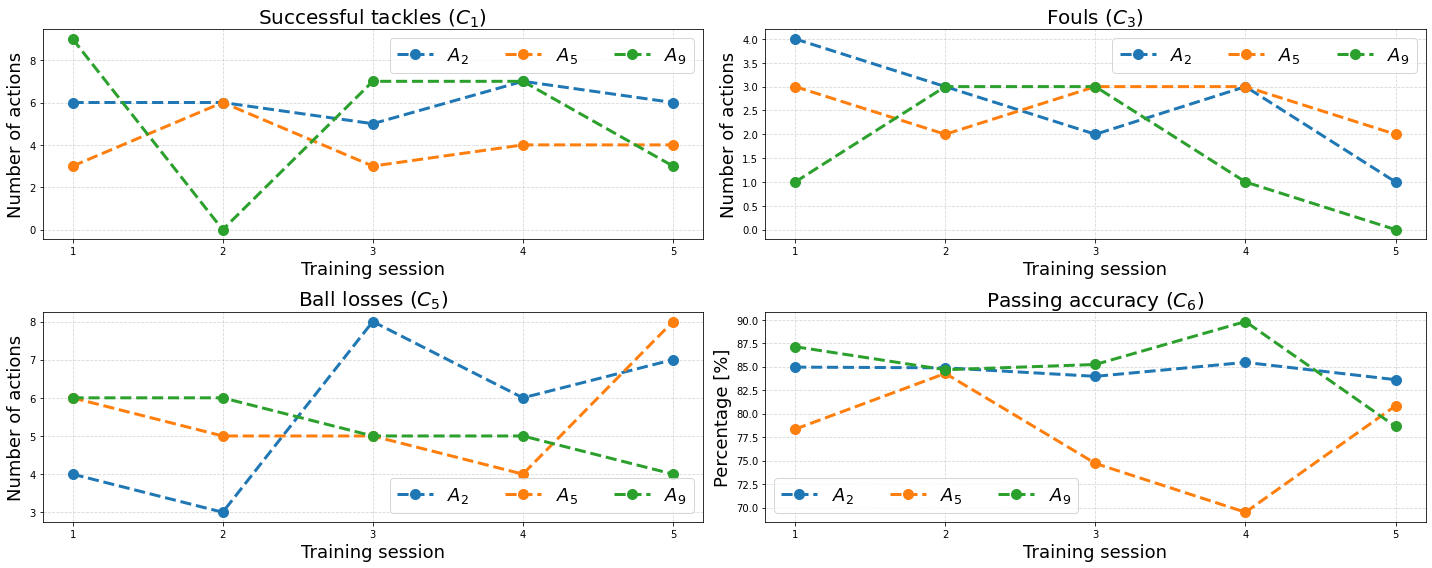

In [5]:
import matplotlib.pyplot as plt

selected_players = df['player'].unique()[[1, 4, 8]]

criteria = ["tackles", "fouls", "losses", "passing_accuracy"]

criteria_labels = {
    "tackles": r"Successful tackles ($C_1$)",
    "fouls": r"Fouls ($C_3$)",
    "losses": r"Ball losses ($C_5$)",
    "passing_accuracy": r"Passing accuracy ($C_6$)",
}

y_labels = {
    "tackles": "Number of actions",
    "fouls": "Number of actions",
    "passing_accuracy": "Percentage [%]",
    "losses": "Number of actions"
}

df_subset = df[df['player'].isin(selected_players)]
df_subset = df_subset.sort_values(by=["player", "session"])

plt.rcParams.update({
    "font.size": 18,
    "axes.titlesize": 20,
    "axes.labelsize": 18,
    "legend.fontsize": 18
})

fig, axes = plt.subplots(2, 2, figsize=(20, 8))
axes = axes.flatten()

for i, crit in enumerate(criteria):
    ax = axes[i]
    
    for player in selected_players:
        player_data = df_subset[df_subset['player'] == player]
        player_id = int(player.split("_")[1])
        label = rf"$A_{{{player_id}}}$"
        ax.plot(
            player_data["session"],
            player_data[crit],
            marker='o',
            linestyle='--',
            label=label,
            linewidth=3,
            markersize=10
        )

    ax.grid(axis='both', linestyle='--', alpha=0.5)
    
    ax.set_title(criteria_labels[crit])
    ax.set_xlabel("Training session")
    ax.set_ylabel(y_labels[crit])
    
    ax.set_xticks([1, 2, 3, 4, 5])
    
    ax.legend(ncol=3)

plt.tight_layout()
plt.savefig('img/crit_data.pdf')
plt.show()

In [16]:
neutral_values = np.array([
    5,    # tackles
    18,   # pressing
    2,    # fouls 
    4,    # aerials
    5,    # losses
    85,   # passing
    30,   # speed
    75    # agility
])

criteria_types = np.array([
    1,   # tackles
    1,   # pressing
    -1,  # fouls
    1,   # aerials
    -1,  # losses
    1,   # passing
    1,   # speed
    1    # agility
])
weights = np.array([0.15, 0.15, 0.1, 0.15, 0.1, 0.15, 0.1, 0.1])

k = 0.5  # sensitivity to variability paramter

grouped = df.groupby("player")

mu = grouped.mean()
sigma = grouped.std()

adjusted_m = mu - k * sigma
matrix_a_m = adjusted_m.values[:, 1:]
adjusted_p = mu + k * sigma
matrix_a_p = adjusted_p.values[:, 1:]

matrix = df.groupby('player').mean()
matrix = matrix.values[:, 1:]
matrix

array([[ 3.6       , 20.8       ,  2.8       ,  3.4       ,  3.        ,
        83.50782065, 33.01512019, 76.00390199],
       [ 1.8       , 16.        ,  3.        ,  2.2       ,  5.6       ,
        92.67105074, 32.37600512, 56.97232115],
       [ 6.        , 19.        ,  2.6       ,  3.2       ,  5.6       ,
        84.57681358, 28.5031675 , 79.41814694],
       [ 3.2       , 13.        ,  2.2       ,  2.        ,  5.2       ,
        81.14314881, 29.32336779, 74.72022833],
       [ 3.6       , 15.2       ,  1.8       ,  1.2       ,  7.        ,
        83.94506905, 33.54465596, 85.21761889],
       [ 4.        , 17.        ,  2.6       ,  2.4       ,  5.6       ,
        77.5388948 , 31.88659687, 60.19250281],
       [ 5.2       , 22.6       ,  4.        ,  4.        ,  5.6       ,
        88.0406406 , 31.04022393, 63.11222141],
       [ 4.2       , 22.        ,  1.8       ,  3.        ,  6.        ,
        93.9752109 , 27.82116914, 87.70190062],
       [ 3.8       , 16.        

In [8]:
matrix_std = df.groupby('player').std()
matrix_std = matrix_std.values[:, 1:]
matrix_std

array([[0.54772256, 0.83666003, 1.09544512, 0.54772256, 2.        ,
        3.64574235, 1.03303095, 3.98147716],
       [2.16794834, 5.24404424, 1.58113883, 1.4832397 , 2.19089023,
        4.31533795, 1.81629547, 5.44086869],
       [0.70710678, 1.58113883, 1.14017543, 0.4472136 , 2.07364414,
        0.75771443, 1.92941934, 6.75417104],
       [0.4472136 , 0.70710678, 1.64316767, 0.        , 1.30384048,
        4.54956186, 1.64425245, 3.79153886],
       [0.89442719, 1.64316767, 1.4832397 , 0.83666003, 1.73205081,
        2.87324641, 1.44978016, 1.70537723],
       [1.22474487, 4.24264069, 0.54772256, 1.14017543, 1.51657509,
        5.69126007, 0.57890453, 2.25153219],
       [0.83666003, 5.41294744, 1.87082869, 1.        , 2.60768096,
        5.64314364, 1.05738885, 4.855005  ],
       [3.96232255, 7.1063352 , 1.30384048, 1.58113883, 2.73861279,
        4.17421381, 2.52253119, 3.12953482],
       [1.09544512, 4.12310563, 2.88097206, 1.51657509, 3.36154726,
        4.03627066, 0.652693

In [9]:
ri, rank = ridm(
    matrix=matrix,
    neutral_values=neutral_values,
    criteria_types=criteria_types,
    weights=weights,
    alpha_=0.88,
    beta_=0.88,
    lambda_=2.25
)

ri_base = ri
ri, rank

(array([-0.0450578 , -0.39137269, -0.14998323, -0.50054915, -0.3383134 ,
        -0.4462277 , -0.08277581, -0.08750554, -0.3120169 ,  0.05669368]),
 array([ 2.,  8.,  5., 10.,  7.,  9.,  3.,  4.,  6.,  1.]))

Sensitivity to variability

In [19]:
ri, rank = ridm(
    matrix=matrix_a_m,
    neutral_values=neutral_values,
    criteria_types=criteria_types,
    weights=weights,
    alpha_=0.88,
    beta_=0.88,
    lambda_=2.25
)

ri_adjusted_m = ri
ri, rank

(array([-0.03730452, -0.44763546, -0.11138418, -0.43648839, -0.3671967 ,
        -0.49726581, -0.14701525, -0.15977781, -0.29894515, -0.16023738]),
 array([ 1.,  9.,  2.,  8.,  7., 10.,  3.,  4.,  6.,  5.]))

In [20]:
ri, rank = ridm(
    matrix=matrix_a_p,
    neutral_values=neutral_values,
    criteria_types=criteria_types,
    weights=weights,
    alpha_=0.88,
    beta_=0.88,
    lambda_=2.25
)

ri_adjusted_p = ri
ri, rank

(array([ 0.00501414, -0.2308034 , -0.08881179, -0.51548795, -0.27683398,
        -0.35793062,  0.02721944,  0.14813264, -0.22135365,  0.22016062]),
 array([ 4.,  7.,  5., 10.,  8.,  9.,  3.,  2.,  6.,  1.]))

In [12]:
for k in [0.0, 0.3, 0.5, 0.8, 1.0]:
    adjusted_m = mu - k * sigma
    matrix_adj_m = adjusted_m.values[:, 1:]

    ri, rank = ridm(matrix_adj_m, neutral_values, criteria_types, weights)

    print(f"k = {k}")
    print(ri)
    print(rank)

k = 0.0
[-0.0450578  -0.39137269 -0.14998323 -0.50054915 -0.3383134  -0.4462277
 -0.08277581 -0.08750554 -0.3120169   0.05669368]
[ 2.  8.  5. 10.  7.  9.  3.  4.  6.  1.]
k = 0.3
[-0.05081527 -0.43302986 -0.12988334 -0.46277643 -0.36725665 -0.48464846
 -0.1208903  -0.14554706 -0.31449308 -0.08676368]
[ 1.  8.  4.  9.  7. 10.  3.  5.  6.  2.]
k = 0.5
[-0.03730452 -0.44763546 -0.11138418 -0.43648839 -0.3671967  -0.49726581
 -0.14701525 -0.15977781 -0.29894515 -0.16023738]
[ 1.  9.  2.  8.  7. 10.  3.  4.  6.  5.]
k = 0.8
[-0.03273755 -0.43887515 -0.10314929 -0.38061518 -0.29979645 -0.50531057
 -0.17397699 -0.21166764 -0.27082947 -0.22474052]
[ 1.  9.  2.  8.  7. 10.  3.  4.  6.  5.]
k = 1.0
[-0.04039163 -0.43791876 -0.10876168 -0.36196376 -0.28009242 -0.49017789
 -0.16626054 -0.25708252 -0.27906407 -0.27589303]
[ 1.  9.  2.  8.  7. 10.  3.  4.  6.  5.]


In [13]:
for k in [0.0, 0.3, 0.5, 0.8, 1.0]:
    adjusted_p = mu + k * sigma
    matrix_adj_p = adjusted_p.values[:, 1:]

    ri, rank = ridm(matrix_adj_p, neutral_values, criteria_types, weights)

    print(f"k = {k}")
    print(ri)
    print(rank)

k = 0.0
[-0.0450578  -0.39137269 -0.14998323 -0.50054915 -0.3383134  -0.4462277
 -0.08277581 -0.08750554 -0.3120169   0.05669368]
[ 2.  8.  5. 10.  7.  9.  3.  4.  6.  1.]
k = 0.3
[-0.00962293 -0.29496945 -0.13211798 -0.51739385 -0.29192497 -0.38190969
 -0.02253841  0.03031033 -0.27608341  0.15207707]
[ 3.  8.  5. 10.  7.  9.  4.  2.  6.  1.]
k = 0.5
[ 0.00501414 -0.2308034  -0.08881179 -0.51548795 -0.27683398 -0.35793062
  0.02721944  0.14813264 -0.22135365  0.22016062]
[ 4.  7.  5. 10.  8.  9.  3.  2.  6.  1.]
k = 0.8
[ 0.01091166 -0.18448501 -0.00926078 -0.51062174 -0.25854395 -0.24840608
  0.09203211  0.30872146 -0.13675575  0.34802643]
[ 4.  7.  5. 10.  9.  8.  3.  2.  6.  1.]
k = 1.0
[ 0.04017843 -0.10855351  0.01619103 -0.47880739 -0.21947537 -0.17677482
  0.12402498  0.37982756 -0.0792475   0.41057175]
[ 4.  7.  5. 10.  9.  8.  3.  2.  6.  1.]


Different risk attitudes

In [75]:
pt_params = [
    (0.88, 0.88, 2.25), # classic prospect
    (0.44, 0.44, 0.99), # New Zealand
    (0.48, 1.72, 3.19), # Romania
    (0.54, 0.90, 1.72), # Chile
    (0.87, 0.90, 1.01), # Tanzania
]
for p in pt_params:
    print(p)
    ri, rank = ridm(
        matrix=matrix,
        neutral_values=neutral_values,
        criteria_types=criteria_types,
        weights=weights,
        alpha_=p[0],
        beta_=p[1],
        lambda_=p[2]
    )

    print(ri)
    print(rank)
    print('')

(0.88, 0.88, 2.25)
[-0.0450578  -0.39137269 -0.14998323 -0.50054915 -0.3383134  -0.4462277
 -0.08277581 -0.08750554 -0.3120169   0.05669368]
[ 2.  8.  5. 10.  7.  9.  3.  4.  6.  1.]

(0.44, 0.44, 0.99)
[ 0.02419851 -0.38188045 -0.09022043 -0.63423678 -0.31201999 -0.55106307
  0.10071926  0.08085422 -0.46006595  0.29511865]
[ 4.  7.  5. 10.  6.  9.  2.  3.  8.  1.]

(0.48, 1.72, 3.19)
[-0.04461002 -0.37775141 -0.08635667 -0.35533297 -0.32657506 -0.32235775
 -0.14149286 -0.15457951 -0.12672349  0.01992843]
[ 2. 10.  3.  9.  8.  7.  5.  6.  4.  1.]

(0.54, 0.9, 1.72)
[-0.05016585 -0.41500056 -0.13820804 -0.49544907 -0.3507877  -0.43935142
 -0.08752179 -0.13593959 -0.29666062  0.0847831 ]
[ 2.  8.  5. 10.  7.  9.  3.  4.  6.  1.]

(0.87, 0.9, 1.01)
[ 0.09184901 -0.3025128  -0.06116095 -0.47700732 -0.26537878 -0.40923951
  0.03479434  0.1228202  -0.27432272  0.13067318]
[ 3.  8.  5. 10.  6.  9.  4.  2.  7.  1.]



Preference oriented evaluation

In [14]:
topsis = pymcdm.methods.TOPSIS()
prefs = topsis(matrix, weights, criteria_types)
rank = topsis.rank(prefs)

print(prefs)
print(rank)

[0.60933518 0.42101498 0.58149107 0.32831122 0.43157169 0.38478962
 0.61579283 0.63881469 0.45883015 0.66328243]
[ 4.  8.  5. 10.  7.  9.  3.  2.  6.  1.]


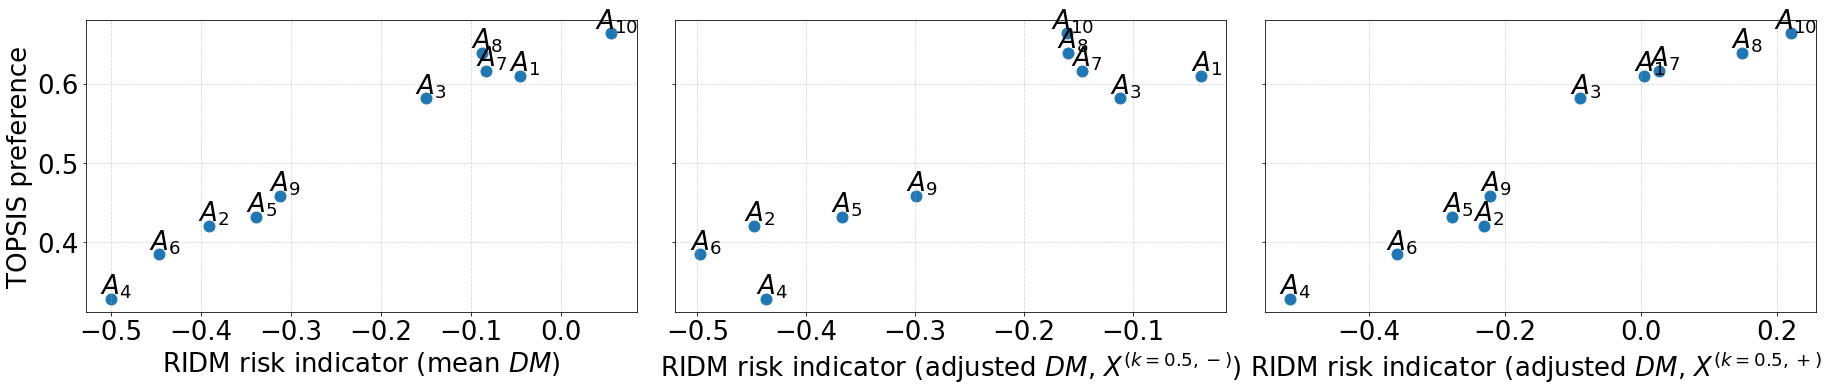

In [29]:
import matplotlib.pyplot as plt

players = [rf"$A_{{{i}}}$" for i in range(1, 11)]
plt.rcParams.update({
    "font.size": 26
})

fig, axes = plt.subplots(1, 3, figsize=(26, 6), sharey=True)

axes[0].scatter(ri_base, prefs, s=120)

for i, txt in enumerate(players):
    axes[0].annotate(txt, (ri_base[i], prefs[i]),
                     textcoords="offset points",
                     xytext=(5, 5),
                     ha='center')

axes[0].set_xlabel("RIDM risk indicator (mean $DM$)", fontsize=26)
axes[0].set_ylabel("TOPSIS preference", fontsize=26)
axes[0].grid(alpha=0.5, linestyle='--')

axes[1].scatter(ri_adjusted_m, prefs, s=120)

for i, txt in enumerate(players):
    axes[1].annotate(txt, (ri_adjusted_m[i], prefs[i]),
                     textcoords="offset points",
                     xytext=(5, 5),
                     ha='center')

axes[1].set_xlabel("RIDM risk indicator (adjusted $DM$, $X^{(k=0.5,-)}$)", fontsize=26)
axes[1].grid(alpha=0.5, linestyle='--')

axes[2].scatter(ri_adjusted_p, prefs, s=120)

for i, txt in enumerate(players):
    axes[2].annotate(txt, (ri_adjusted_p[i], prefs[i]),
                     textcoords="offset points",
                     xytext=(5, 5),
                     ha='center')

axes[2].set_xlabel("RIDM risk indicator (adjusted $DM$, $X^{(k=0.5,+)}$)", fontsize=26)
axes[2].grid(alpha=0.5, linestyle='--')

plt.tight_layout()
plt.savefig('img/scores_plot.pdf')
plt.show()